# 03 — Stock Returns

EDA on price and return data. Checks data quality, plots price series with event markers, and examines return distributions.

**Prerequisite:** Run notebook 01 first.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from utils import TICKERS, EVENT_DATES, BENCHMARKS

prices  = pd.read_csv('../data/raw/stocks/prices.csv',  index_col=0, parse_dates=True)
returns = pd.read_csv('../data/raw/stocks/returns.csv', index_col=0, parse_dates=True)

print(f'Prices:  {prices.shape}  |  {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Returns: {returns.shape}')

/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Prices:  (475, 12)  |  2024-07-01 → 2026-05-04
Returns: (474, 12)


## 3a. Normalised price performance (indexed to 100)

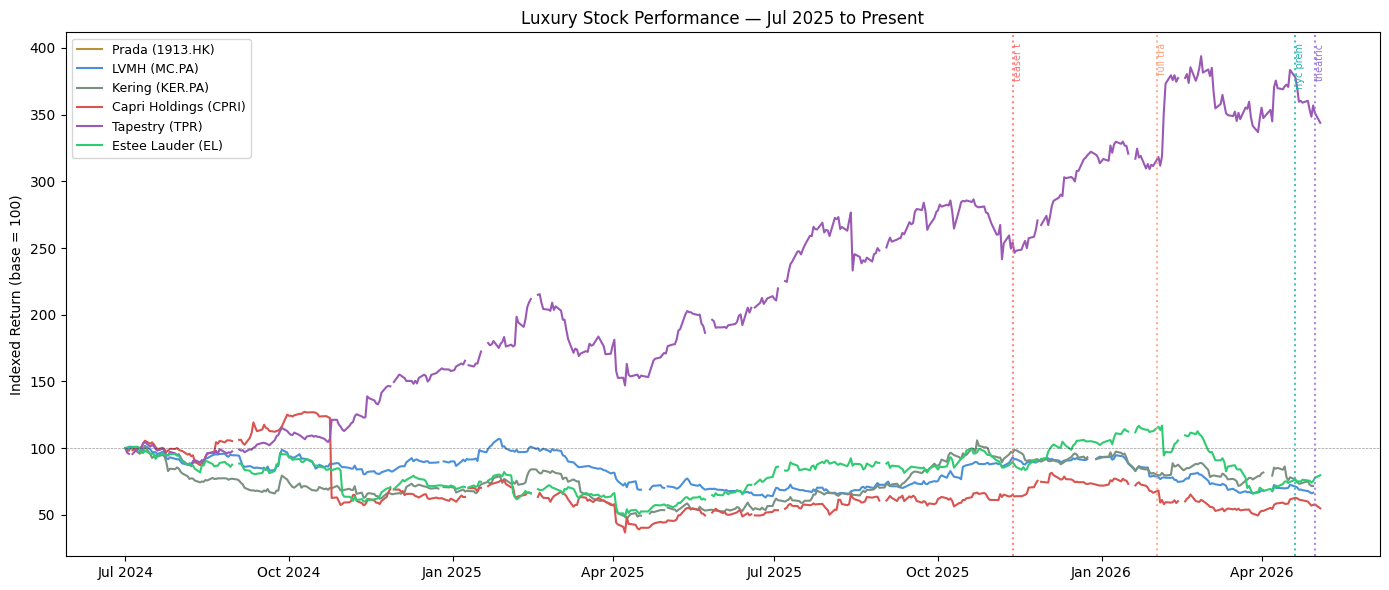

In [2]:
ticker_cols = [t for t in TICKERS if t in prices.columns]
base_date   = prices.index[0]
normalised  = prices[ticker_cols].div(prices[ticker_cols].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#B5933A', '#4A90D9', '#7A9080', '#D9534F', '#9B59B6', '#2ECC71']

for col, color in zip(ticker_cols, colors):
    label = TICKERS.get(col, col)
    ax.plot(normalised.index, normalised[col], label=f'{label} ({col})', color=color, linewidth=1.5)

event_colors = ['#FF6B6B', '#FFA07A', '#20B2AA', '#9370DB']
for (ev_name, ev_date), ev_color in zip(EVENT_DATES.items(), event_colors):
    ax.axvline(pd.Timestamp(ev_date), color=ev_color, linestyle=':', alpha=0.8, linewidth=1.5)
    ax.text(pd.Timestamp(ev_date), ax.get_ylim()[1] * 0.98,
            ev_name.replace('_',' ')[:8], rotation=90, fontsize=7, color=ev_color, va='top')

ax.axhline(100, color='black', linewidth=0.5, alpha=0.4, linestyle='--')
ax.set_ylabel('Indexed Return (base = 100)')
ax.set_title('Luxury Stock Performance — Jul 2025 to Present')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('../results/figures/price_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3b. Return distributions

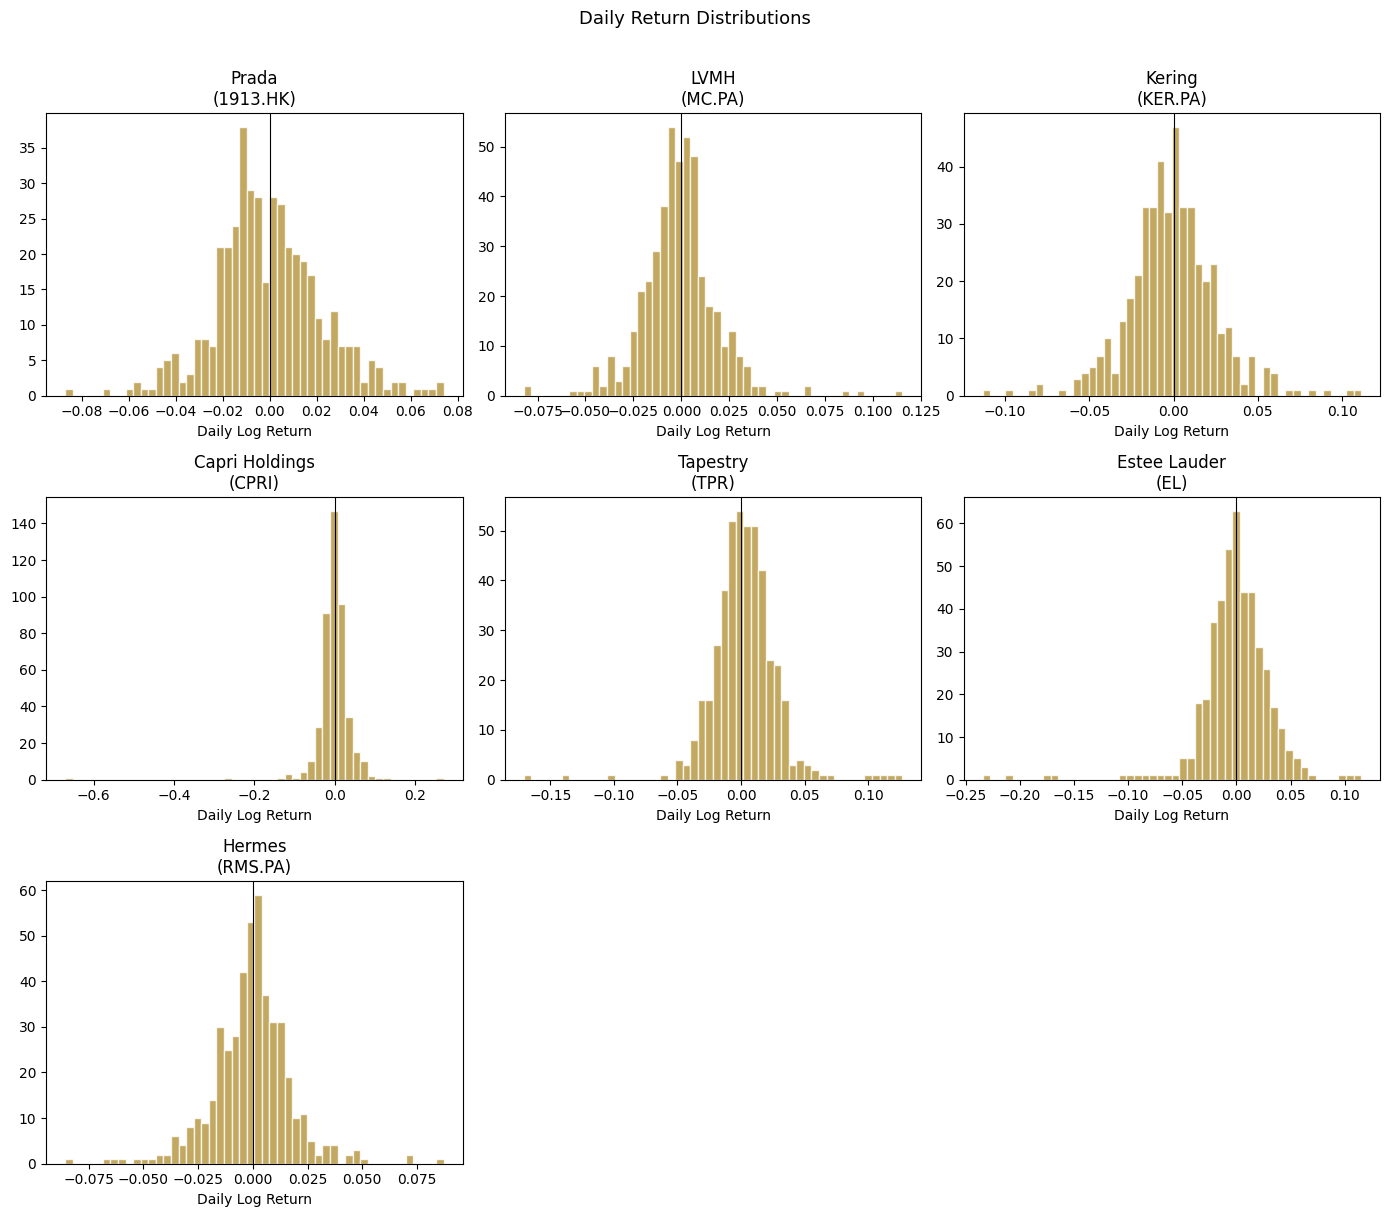

In [3]:
import math
n = len(TICKERS)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, (ticker, name) in enumerate(TICKERS.items()):
    if ticker not in returns.columns:
        continue
    r = returns[ticker].dropna()
    axes[i].hist(r, bins=50, color='#B5933A', alpha=0.8, edgecolor='white')
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{name}\n({ticker})')
    axes[i].set_xlabel('Daily Log Return')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Daily Return Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3c. Correlation matrix

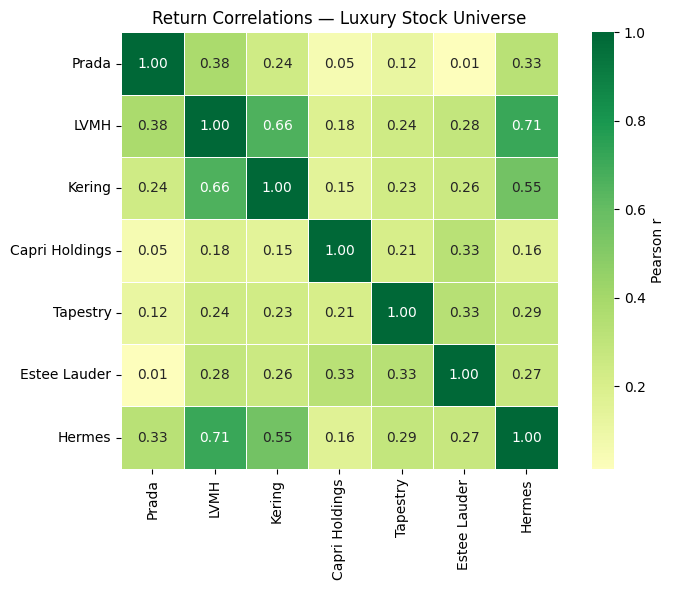

                Prada   LVMH  Kering  Capri Holdings  Tapestry  Estee Lauder  \
Prada           1.000  0.380   0.242           0.049     0.116         0.013   
LVMH            0.380  1.000   0.663           0.179     0.239         0.284   
Kering          0.242  0.663   1.000           0.146     0.235         0.256   
Capri Holdings  0.049  0.179   0.146           1.000     0.212         0.328   
Tapestry        0.116  0.239   0.235           0.212     1.000         0.332   
Estee Lauder    0.013  0.284   0.256           0.328     0.332         1.000   
Hermes          0.327  0.714   0.555           0.164     0.288         0.269   

                Hermes  
Prada            0.327  
LVMH             0.714  
Kering           0.555  
Capri Holdings   0.164  
Tapestry         0.288  
Estee Lauder     0.269  
Hermes           1.000  


In [4]:
ticker_returns = returns[[t for t in TICKERS if t in returns.columns]].dropna()
corr = ticker_returns.corr()
corr.columns = [TICKERS.get(c, c) for c in corr.columns]
corr.index   = [TICKERS.get(c, c) for c in corr.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Return Correlations — Luxury Stock Universe')
plt.tight_layout()
plt.savefig('../results/figures/return_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr.round(3))